This notebook has been inspired by the book from Sebastian Raschka "Python Machine Learning".

## Multi Layer Perceptron

We are going in this notebook to code a multi layer perceptron from scratch. A multi layer perceptron is a sequence of matrix computation, each followed by a non- linear function. In this notebook we are going to use as non linear function the sigmoid - even if currently ReLu is a more used function. We are going to show how to code a simple neural network.



### Exercise 1 - Define a function that compute the sigmoid and plot the function

The sigmoid is defined as:

$$
\phi(z) = \frac{1}{1+e^{-z}}
$$

In [2]:
import numpy as np

def sigmoid(z):
    ## compute the sigmoid
    z = 1/(1+np.exp(-z))
    return z

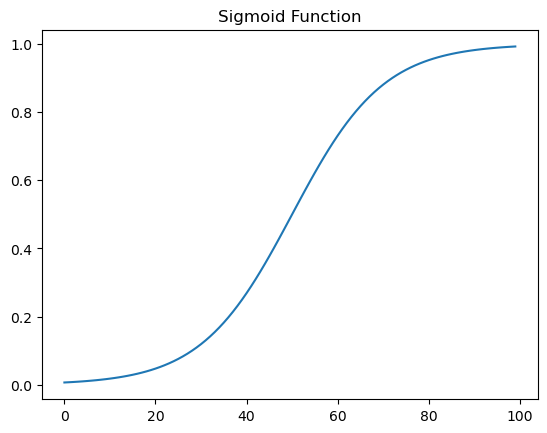

In [5]:
import matplotlib.pyplot as plt

## Create a range of values for z
z = np.arange(-5, 5, 0.1)
z = sigmoid(z)

## Plot the sigmoid function
plt.plot(z)
plt.title("Sigmoid Function")
plt.show()

### Exercise 2 - one hot function

Write a function that takes in input a list of values and returns the one_hot values of them.

In [ ]:
y = [2, 1, 2, 3, 1, 4]
y = np.array(y, dtype=int)

hot_matrix = np.zeros((len(y), len(set(y))))
## create a one-hot vector

for i in range(len(y)):
    hot_matrix[i, y[i] - 1] = 1






[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]]
[0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1.]


In [27]:
def one_hot(y):
    y = np.array(y, dtype=int)
    hot_matrix = np.zeros((len(y), len(set(y))))
    ## create a one-hot vector

    for i in range(len(y)):
        hot_matrix[i, y[i] - 1] = 1
    return hot_matrix

In [28]:
assert (one_hot([1,2]) == np.array([[1,0], [0., 1]]) ).all()
assert (one_hot([2,1]) == np.array([[0,1], [1., 0]]) ).all()
assert (one_hot([2, 1,2,3,1, 4]) == np.array([[0.,1.,0.,0.], [1,0.,0.,0.], [0.,1.,0., 0], [0, 0, 1, 0], [1.,0.,0.,0.], [0., 0., 0., 1.]])).all()

### Exercise 3 - Cost function - logistic cost function

We are going to use as cost function the logistic cost function (with no regularization). We are also going to normalize the logistic cost functionwith respect to the number of values we are considering, to be able to evaluate it on datasets of different lenghts.

$$
C =-\frac{1}{n} \sum_{1}^{n}{ \bigg( y^{i}*\log(f(x^{i}))+(1-y^{i}) *\log(1-f(x^{i})) \bigg)}
$$

where

- n isthe number of datapoints
- $y^{i}$ is the label for the $i^{th}$ element
- $f$ is the prediction function
- $x^{i}$ is the $i^{th}$ element of the dataset


In [29]:
def cost_function(y_label, prediction):
    sum_C = -np.sum(
        y_label * np.log(prediction) + 
        (1 - y_label) * np.log(1 - prediction))
    return sum_C/len(y_label)



In [30]:
assert np.abs(cost_function(np.array([[1,0]]), np.array([[0.9,0.1]])) - 0.21072103131565256) < 0.000001
assert np.abs(cost_function(np.array([[1,0,], [0, 1]]), np.array([[0.999,0.1], [0.5, 0.5]])) - 0.7463276885556502) < 0.000001

###  Exercise 4 - Forward propagation 

In the following we are going to consider a multi-layer perceptron having only one hidden layer of a certain size. The non-linear function is going to be the sigmoid.

Let X be data. The algorithm to compute the forward pass is the following:



$$z_{h} = X*w_{h} + b_{h} $$
$$a_{h} = \phi(z_{h})$$
$$z_{out} = a_{h}*w_{out} + b_{out}$$
$$a_{out} = \phi(z_{out})$$

Function should return values for $z_{h}, a_{h}, z_{out}, a_{out}$.

In [31]:
def forward(X, w_h, b_h, w_out, b_out):
    zh = np.dot(X, w_h) + b_h
    ah = sigmoid(zh)
    zo = np.dot(ah, w_out) + b_out
    ao = sigmoid(zo)
    return zh, ah, zo, ao
    ## return the hidden layer and output layer

In [32]:
forward_X_test = [[1,0,1]]
forward_wh_test = [[0,1], [1,0], [1,1]]
forward_bh_test = [1,1]
forward_wout_test = [[1,4,5], [2,-1, -1]]
forward_bout_test = [1,2,-1]

t1, t2, t3, t4 = forward(forward_X_test, forward_wh_test,forward_bh_test, forward_wout_test, forward_bout_test)

assert (t1 == np.array([[2,3]])).all()
assert (t2 - np.array([[0.88079708, 0.95257413]]) < 0.00001).all()
assert (t3 - np.array([[3.78594533 ,4.57061419, 2.45141126]]) < 0.000001).all()
assert (t4 - np.array([[0.99987661, 0.99908895, 0.99752738]]) < 0.00001).all()

### Exercise 5 - Back propagation

We are going to need before being able to train a neural network, the back propagation step. In this step we are going to compute the error the model is doing with respect to the true label and backpropagate this information to every layer. Then we will update the weight of each layer with the information from the gradient.

We are going to compute:


$$\delta_{out} = a_{out} - y$$
$$\frac{\partial \phi(z_{h})}{\partial z_{h}} = a_{h}*(1-a_{h})$$
$$\delta_{h} = (\delta_{out} w_{out}^{T})*(a_{h}*(1-a_{h}))$$
$$\nabla(w_{h}) = X^{T} \delta_{h}$$
$$\nabla(b_{h}) = \sum{\delta_{h}}$$
$$\nabla(w_{out}) = a_{h}^{T}\delta_{out}$$
$$\nabla(b_{out}) = \sum{\delta_{out}}$$


It should return the values of


$$\nabla(w_{h})$$
$$\nabla(b_{h})$$
$$\nabla(w_{out})$$
$$\nabla(b_{out})$$


In [35]:
def backpropagation(X, y, z_h, a_h, z_out, a_out, w_out):
    delta_out = a_out - y
    
    grad_sigmoid = a_h * (1 - a_h)
    delta_h = np.dot(delta_out, w_out.T) * grad_sigmoid
    grad_w_out = np.dot(a_h.T, delta_out)
    grad_b_out = np.sum(delta_out, axis=0)
    grad_w_h = np.dot(X.T, delta_h)
    grad_b_h = np.sum(delta_h, axis=0)
    return grad_w_h, grad_b_h, grad_w_out, grad_b_out

    
    

In [36]:
g1, g2, g3, g4 = backpropagation(np.array(forward_X_test), [0,1,0], t1, t2, t3, t4, np.array(forward_wout_test))


assert np.abs((g1 - np.array([[0.58168091, 0.04721922],
 [0.  ,       0.        ],
 [0.58168091, 0.04721922]]))).sum() < 0.0001
assert np.abs((g2 - np.array([0.58168091, 0.04721922]))).sum() < 0.0001
assert np.abs((g3 - np.array([[ 0.86125738, -0.00902424,  0.81091868],
 [ 0.93144212, -0.00975964,  0.87700127]]))).sum() < 0.0001
assert np.abs((g4 - np.array([ 0.97781589, -0.01024554,  0.92066459]))).sum() < 0.0001


### Exercice 6 - Putting all together

We are going to create a class called MultiLayerPerceptron that takes as input in the init:

- the number of features of the dataset $n_{features}$
- the number of hidden neurons $n_{hidden}$
- the number of output neurons $n_{output}$ (number of unique labels in target)

We are going to initiate as class variables:
- bias vector $b_{h}$ as a set of zeros of length $n_{hidden}$
- matrix $w_{h}$ as a random normal matrix with size $(n_{features}, n_{hidden})$
- bias vector $b_{out}$ as a set of zeros of length $n_{output}$
- matrix $w_{out}$ as a random normal matrix with size $(n_{hidden}, n_{output})$

Then we will integrate the two functions forward and backprop by using the class variables instead of having a static function. We are going to use both in the train method

In [62]:
class MultiLayerPerceptron:
    def __init__(self, n_features, n_hidden, n_output):
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_output = n_output

        # Initialize weights and biases
        self.w_h = np.random.randn(n_features, n_hidden)
        self.b_h = np.random.randn(n_hidden)
        self.w_out = np.random.randn(n_hidden, n_output)
        self.b_out = np.random.randn(n_output)
        
    def forward(self, X):
        zh = np.dot(X, self.w_h) + self.b_h
        ah = sigmoid(zh)
        zo = np.dot(ah, self.w_out) + self.b_out
        ao = sigmoid(zo)
        return zh, ah, zo, ao
    
    
    
    def backprop(self, X_batch, y_batch, z_h, a_h, z_out, a_out):
        return backpropagation(X_batch, y_batch, z_h, a_h, z_out, a_out, self.w_out)

    def train(self, X_train, y_train, X_val, y_val, epochs, batch_size, learning_rate):
        epoch_loss_train = []
        epoch_loss_val = []
        batch_loss = []
        
        for idx_epoch in range(epochs):
            # iterate over minibatches
            indices = np.arange(X_train.shape[0])
            batch_num = 1
            for start_idx in range(0, indices.shape[0] - batch_size + 1, batch_size):
                batch_idx = indices[start_idx:start_idx + batch_size]
                X_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]
                
                # forward propagation
                z_h, a_h, z_out, a_out = self.forward(X_batch)
                
                batch_cost = cost_function(y_batch, a_out)
                batch_num += 1
                batch_loss.append(batch_cost)
                grad_w_h, grad_b_h, grad_w_out, grad_b_out = self.backprop(X_batch, y_batch, z_h, a_h, z_out, a_out) 
                
                # Weight updates - do not forget the learning rate!
                self.w_h = self.w_h - learning_rate * grad_w_h
                self.b_h = self.b_h - learning_rate * grad_b_h
                self.w_out = self.w_out - learning_rate * grad_w_out
                self.b_out = self.b_out - learning_rate * grad_b_out
            
            _, _, _, a_out = self.forward(X_train)
            
            cost = cost_function(y_train, a_out)
            self.predict(X_val)
            
            _, _, _, a_out_val = self.forward(X_val)
            cost_val = cost_function(y_val, a_out_val)
            epoch_loss_train.append(cost)
            epoch_loss_val.append(cost_val)
            print(f'Epoch {idx_epoch}: train {cost} - eval {cost_val}')
        return epoch_loss_train, epoch_loss_val, batch_loss
    
    def predict(self, X):
        _, _, _, prediction = self.forward(X)
        return np.argmax(prediction, axis=1)
    
    def predict_proba(self, X):
        _, _, _, prediction = self.forward(X)
        return prediction

### Import the datasets

We are going to use the digits dataset from sklearn. We will build a train, validation and test set.

In [42]:
from sklearn.datasets import load_digits

In [43]:
digits = load_digits()

In [44]:
X = digits.data
y = one_hot(digits.target)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)

### Exercice 7 - training a classifier

Create a new object nn with the correct dimension for values $n_{features}$ and $n_{output}$. You can choose the number of hidden neurons you want to use.

Call the *train* method with different epochs, batch_size and learning_rate.

In [63]:
nn_code = MultiLayerPerceptron(n_features=X.shape[1], n_hidden=100, n_output=y.shape[1])
nn_code.train(X_train, y_train, X_val, y_val, epochs=100, batch_size=10, learning_rate=0.01)

Epoch 0: train 1.7229659501571146 - eval 1.8715151824829155
Epoch 1: train 1.2464684591581945 - eval 1.3731044713271099
Epoch 2: train 0.8649746031761045 - eval 1.0586167821711274
Epoch 3: train 0.7566261720377682 - eval 0.924661835292071
Epoch 4: train 0.6082677250527999 - eval 0.6944455607346125
Epoch 5: train 0.5409081959373956 - eval 0.7327708924510036
Epoch 6: train 0.44399552489063876 - eval 0.6291745985562895
Epoch 7: train 0.4179652465553305 - eval 0.6361361328134767
Epoch 8: train 0.37821260779220917 - eval 0.6138283356695882
Epoch 9: train 0.3708336665542102 - eval 0.6028778326782498
Epoch 10: train 0.3320107546547695 - eval 0.59187947471029
Epoch 11: train 0.3033507674773404 - eval 0.533838178676918
Epoch 12: train 0.27268035486849956 - eval 0.5197639708046651
Epoch 13: train 0.24470582472151492 - eval 0.5122038376351256
Epoch 14: train 0.22826324149968355 - eval 0.4982471961955476
Epoch 15: train 0.221135403620181 - eval 0.4963667980241762
Epoch 16: train 0.2083332529753543

([1.7229659501571146,
  1.2464684591581945,
  0.8649746031761045,
  0.7566261720377682,
  0.6082677250527999,
  0.5409081959373956,
  0.44399552489063876,
  0.4179652465553305,
  0.37821260779220917,
  0.3708336665542102,
  0.3320107546547695,
  0.3033507674773404,
  0.27268035486849956,
  0.24470582472151492,
  0.22826324149968355,
  0.221135403620181,
  0.20833325297535432,
  0.2017673761495082,
  0.18628083611784302,
  0.1680649957766778,
  0.16544128620063447,
  0.15476477123389873,
  0.15002792960168831,
  0.14465886282418525,
  0.1386618499167248,
  0.13722757741621178,
  0.13032285134159063,
  0.13170796205544705,
  0.12405324576388635,
  0.11970556812226145,
  0.11430998882289928,
  0.11308457967718154,
  0.10897854503220754,
  0.1062284354654161,
  0.10331698852056126,
  0.10052182538649454,
  0.09872383933561234,
  0.09568900568012517,
  0.09380678713289133,
  0.0966553203596296,
  0.09017936908487956,
  0.08847202702337456,
  0.08725753945183307,
  0.0852276866614214,
  0.08

In [64]:
epoch_value, epoch_loss_val, batch_value = #train model with given values

SyntaxError: invalid syntax (1850265217.py, line 1)

### Exercice 8 - compute accuracy metrics for train, test and valuation

### Exercice 9 - show examples of mislabelled images for training, valuation and test sets

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline



### Exercice 9 - plot training graphs

Plot a graph having epoch loss for train and validation sets. 

Add to the plot a graph having epoch loss for batch loss. 

# Using pytorch

By using pytorch documentation, replicate what has been done from scratch.

Change the definition of the network to see what works better.

In [ ]:
import torch
from torch import nn

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 40),
            nn.ReLU(),
            nn.Linear(40,10),
            nn.ReLU(),
            nn.Linear(10,10)
            )
        
    def forward(self, x):
        logits = self.model(x)
        return logits
    
       
    def train(self, X_train, y_train, X_val, y_val, epochs, batch_size, learning_rate):
        epoch_loss_train = []
        epoch_loss_val = []
        batch_loss = []
        criterion = #use CrossEntropyLoss
        optimizer = #choose an optim  
        for idx_epoch in range(epochs):
            # iterate over minibatches
            indices = np.arange(X_train.shape[0])
            batch_num = 1
            for start_idx in range(0, indices.shape[0] - batch_size + 1, batch_size):
                batch_idx = indices[start_idx:start_idx + batch_size]
                
                optimizer.zero_grad()

                X_batch = torch.from_numpy(X_train[batch_idx])
                y_batch = torch.from_numpy(y_train[batch_idx])

                outputs = #compute the output
                loss = # compute the loss
                
                # compute the loss and optimize the code
                
                batch_loss.append(loss.item())
            
            # compute the loss for train and val
            pred_train = 
            loss_train =
            
            pred_val = 
            loss_val = 
            print(f'Loss: {loss.item()} - {loss_val.item()}')
            epoch_loss_train.append(loss_train.item() )
            epoch_loss_val.append(loss_val.item() )

        return epoch_loss_train, epoch_loss_val, batch_loss
    
    def compute_accuracy(self, X_values, y_values):
        pass

In [ ]:
torch_nn = NeuralNetwork()

In [ ]:
loss_train, loss_val, batch_loss = # train the model

### Exercice 10 

Evaluate the accuracy for train, evaluation and test set. Add a method compute_accuracy to the class NeuralNetwork

### Exercice 11

Plot the graphs of training for both training and evaluation set.

### Exercice 12 

Find the set of images that are wrongly classified by both models.

### Exercice 13 - Use a convolutional neuronal network instead of a linear network (optional)